Testando PCA na prática com dataset de Expectativa de Vida no Afeganistão até 2014

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('Afegan_Raw.csv', index_col=0, delimiter=';')
df.head(10)

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,,,,,,,,,,,,,,,,,
2014,59.9,271,64,0.01,7352358168,62,492,18.6,86,58,8.18,62,327582,17.5,17.5,0.476,10.0
2013,59.9,268,66,0.01,7321924272,64,430,18.1,89,62,8.13,64,31731688,17.7,17.7,0.470,9.9
2012,59.5,272,69,0.01,781842153,67,2787,17.6,93,67,8.52,67,3696958,17.9,18.0,0.463,9.8
2011,59.2,275,71,0.01,7097108703,68,3013,17.2,97,68,7.87,68,2978599,18.2,18.2,0.454,9.5
2010,58.8,279,74,0.01,7967936736,66,1989,16.7,102,66,9.20,66,2883167,18.4,18.4,0.448,9.2
2009,58.6,281,77,0.01,5676221682,63,2861,16.2,106,63,9.42,63,284331,18.6,18.7,0.434,8.9
2008,58.1,287,80,0.03,2587392536,64,1599,15.7,110,64,8.33,64,2729431,18.8,18.9,0.433,8.7
2007,57.5,295,82,0.02,1091015598,63,1141,15.2,113,63,6.73,63,26616792,19.0,19.1,0.415,8.4
2006,57.3,295,84,0.03,1717151751,64,1990,14.7,116,58,7.43,58,2589345,19.2,19.3,0.405,8.1


In [3]:
df.shape

(15, 17)

In [4]:
#PASSO A PASSO PARA AUTO-ESCALAR OS DADOS
#1 - CALCULANDO A MÉDIA DE CADA VARIÁVEL
dfn = df.mean()

#2- CALCULANDO O DESVIO PADRÃO DE CADA VARIÁVEL
dfdp = df.std()

#3 - AUTO-ESCALANDO OS DADOS
dfauto = (df-dfn)/dfdp

dfauto.head(10)
#dfauto.shape

#############################
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#dfauto = scaler.fit_transform(dfauto.astype(float))
#display(dfauto)

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,,,,,,,,,,,,,,,,,
2014,1.354619,0.020364,-1.789967,-0.627896,1.410223,-1.344103,-0.837956,1.601259,-1.798195,0.362721,-0.113208,0.551570,-0.713928,0.163652,0.298303,1.345650,1.236943
2013,1.354619,-0.019479,-1.556493,-0.627896,1.399983,-0.282969,-0.864588,1.360106,-1.565670,0.576086,-0.185162,0.656299,2.067607,0.197746,0.327644,1.221180,1.172294
2012,1.103764,0.033645,-1.206282,-0.627896,-0.800513,1.308732,0.147849,1.118952,-1.255636,0.842793,0.376080,0.813391,-0.415494,0.231841,0.371656,1.075967,1.107645
2011,0.915622,0.073488,-0.972808,-0.627896,1.324341,1.839299,0.244927,0.926029,-0.945603,0.896134,-0.559323,0.865756,-0.479121,0.282982,0.400998,0.889263,0.913700
2010,0.664767,0.126612,-0.622597,-0.627896,1.617342,0.778165,-0.194928,0.684876,-0.558060,0.789452,1.354654,0.761027,-0.487574,0.317076,0.430339,0.764794,0.719754
2009,0.539339,0.153174,-0.272386,-0.627896,0.846265,-0.813536,0.179636,0.443722,-0.248027,0.629428,1.671252,0.603934,-0.717759,0.351170,0.474351,0.474366,0.525808
2008,0.225770,0.232860,0.077825,2.063086,-0.193012,-0.282969,-0.362450,0.202569,0.062007,0.682769,0.102654,0.656299,-0.501191,0.385264,0.503692,0.453621,0.396511
2007,-0.150513,0.339108,0.311299,0.717595,-0.696487,-0.813536,-0.559182,-0.038585,0.294532,0.629428,-2.199874,0.603934,1.614568,0.419359,0.533034,0.080213,0.202566
2006,-0.275941,0.339108,0.544772,2.063086,-0.485816,-0.282969,-0.194498,-0.279738,0.527057,0.362721,-1.192518,0.342113,-0.513598,0.453453,0.562375,-0.127235,0.008620


In [5]:
#CORRELACIONAMENTO ENTRE VARIÁVEIS
corr = dfauto.iloc[:,0:17].corr()
corr

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Life expectancy,1.000000,0.067537,-0.933430,-0.095230,0.767439,0.296613,-0.593919,0.983081,-0.929881,0.716072,0.198989,0.744803,0.057482,0.591252,0.677882,0.980128,0.975305
Adult Mortality,0.067537,1.000000,-0.101476,0.200053,-0.016126,-0.000872,0.132412,0.114448,-0.097086,0.090962,0.145882,0.084832,-0.358448,-0.301937,0.403047,0.214960,0.149883
infant deaths,-0.933430,-0.101476,1.000000,0.299178,-0.777185,-0.126823,0.358367,-0.974847,0.999168,-0.661831,-0.121116,-0.695700,0.000707,-0.297367,-0.433697,-0.932985,-0.918203
Alcohol,-0.095230,0.200053,0.299178,1.000000,-0.307484,0.013598,-0.289742,-0.137204,0.287534,0.059467,-0.286383,0.048983,0.024816,0.295228,0.372695,-0.019804,0.005799
percentage expenditure,0.767439,-0.016126,-0.777185,-0.307484,1.000000,0.105538,-0.372490,0.777230,-0.762713,0.516994,0.285991,0.546786,0.007437,0.344165,0.377368,0.743409,0.726314
Hepatitis B,0.296613,-0.000872,-0.126823,0.013598,0.105538,1.000000,-0.279594,0.189363,-0.122195,0.085712,0.286360,0.068002,0.019452,0.442411,0.431813,0.238160,0.235366
Measles,-0.593919,0.132412,0.358367,-0.289742,-0.372490,-0.279594,1.000000,-0.486544,0.351717,-0.269967,-0.132252,-0.304332,-0.358228,-0.902957,-0.773427,-0.536278,-0.519546
BMI,0.983081,0.114448,-0.974847,-0.137204,0.777230,0.189363,-0.486544,1.000000,-0.973396,0.728365,0.124071,0.758824,0.022422,0.458913,0.588753,0.984988,0.978309
under-five deaths,-0.929881,-0.097086,0.999168,0.287534,-0.762713,-0.122195,0.351717,-0.973396,1.000000,-0.649573,-0.104737,-0.683712,-0.014439,-0.288910,-0.422838,-0.929872,-0.916119
Polio,0.716072,0.090962,-0.661831,0.059467,0.516994,0.085712,-0.269967,0.728365,-0.649573,1.000000,-0.055466,0.997883,-0.222992,0.400280,0.486859,0.758909,0.812699


<Axes: >

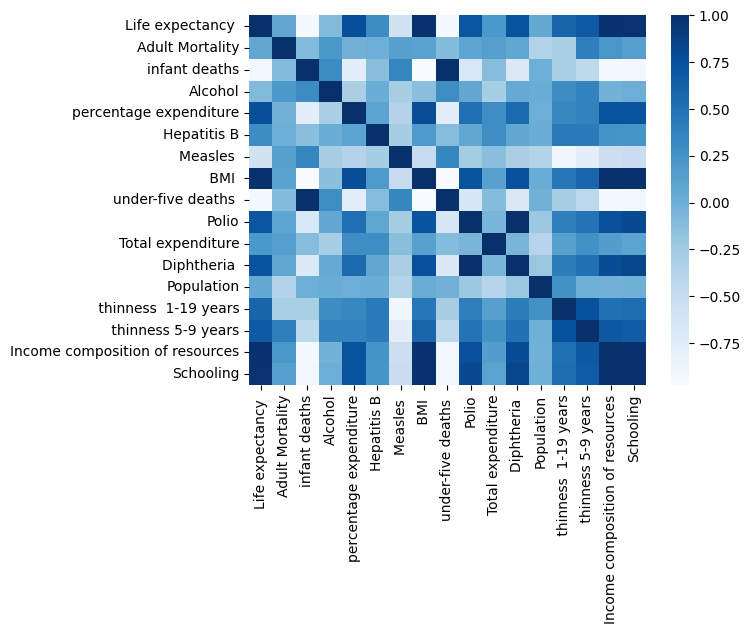

In [6]:
#HEATMAP DA MATRIZ DE CORRELAÇÕES
sns.heatmap(corr,
            xticklabels= corr.columns,
            yticklabels= corr.columns, cmap='Blues')


In [7]:
# CORRELAÇÃO
X = np.asarray(dfauto.iloc[:,0:16])
S = np.cov(X)

In [8]:
X

array([[ 1.35461902,  0.02036421, -1.78996651, -0.62789559,  1.41022262,
        -1.34410306, -0.83795643,  1.60125898, -1.79819492,  0.36272102,
        -0.11320767,  0.55157018, -0.71392796,  0.16365214,  0.29830316,
         1.34564963],
       [ 1.35461902, -0.01947881, -1.55649262, -0.62789559,  1.39998274,
        -0.28296907, -0.86458822,  1.36010552, -1.56566972,  0.57608633,
        -0.1851617 ,  0.6562987 ,  2.06760667,  0.19774633,  0.32764445,
         1.2211805 ],
       [ 1.10376365,  0.03364522, -1.20628178, -0.62789559, -0.80051282,
         1.30873193,  0.1478494 ,  1.11895206, -1.25563611,  0.84279296,
         0.37607972,  0.81339147, -0.4154945 ,  0.23184053,  0.37165639,
         1.07596651],
       [ 0.91562212,  0.07348825, -0.97280788, -0.62789559,  1.32434062,
         1.83929893,  0.24492657,  0.92602929, -0.9456025 ,  0.89613429,
        -0.55932264,  0.86575573, -0.47912122,  0.28298182,  0.40099769,
         0.88926281],
       [ 0.66476674,  0.12661229, -0

In [9]:
#variância de cada variável
np.diagonal(X)

array([ 1.35461902, -0.01947881, -1.20628178, -0.62789559,  1.61734202,
       -0.81353607, -0.36245009, -0.03858455,  0.52705713,  0.36272102,
        0.76463146, -0.54807923,  1.20387019, -2.46160092, -1.9022939 ])

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)

In [11]:
pca.fit(X)
pca.components_

array([[ 3.53546844e-01,  3.88603637e-02, -3.24952367e-01,
        -1.73715016e-02,  2.78652324e-01,  1.02570228e-01,
        -2.19313193e-01,  3.47155889e-01, -3.22145704e-01,
         2.81159799e-01,  6.73386378e-02,  2.90479436e-01,
         4.77603120e-05,  2.19876500e-01,  2.58577537e-01,
         3.51945920e-01],
       [-1.10242444e-02, -1.28542148e-01,  2.12361150e-01,
         4.06717321e-01, -1.56151982e-01,  2.52232809e-01,
        -4.49205874e-01, -1.02870549e-01,  2.10729906e-01,
        -1.01789927e-01, -4.81742888e-02, -1.02562499e-01,
         2.85775818e-01,  4.65387519e-01,  3.23101290e-01,
        -4.70120457e-02],
       [-5.42354142e-02,  5.86727467e-01,  1.17439893e-01,
         3.11033757e-01, -1.44845830e-01,  1.23300297e-01,
         8.90688215e-02, -6.36778767e-02,  1.25474493e-01,
         1.05847292e-01,  2.63909803e-01,  8.85532845e-02,
        -5.33292816e-01, -8.02880307e-02,  3.12020000e-01,
         3.82416876e-02],
       [ 4.17352298e-02, -7.47632286e

In [12]:
#variáveis dos componentes principais

pca.explained_variance_
np.round(pca.explained_variance_ratio_,2)

array([0.49, 0.15, 0.11, 0.1 , 0.06, 0.04, 0.02, 0.02, 0.01, 0.  ])

In [13]:
pca.explained_variance_ratio_.cumsum()

array([0.48752994, 0.63665774, 0.74668984, 0.84401231, 0.90297407,
       0.947257  , 0.96709091, 0.98439108, 0.99690845, 0.99969634])

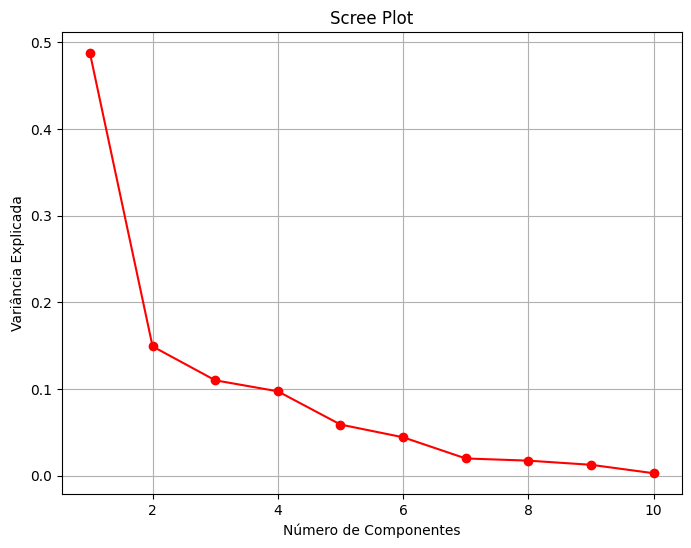

In [14]:
fig = plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, "ro-")
plt.title("Scree Plot")
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Explicada")
plt.grid(True)
plt.show()

In [ ]:
pca.transform(X)

#Projeta em relação ao futuro, diferente do FIT que treina em relação aos dados passados

array([[ 3.48757166e+00, -1.56230286e+00, -6.69762028e-01,
        -2.51563459e-01,  6.39975101e-01, -1.29177153e+00,
         6.61023967e-01, -5.95851307e-01, -7.91379510e-01,
        -5.35596550e-03],
       [ 3.42033460e+00, -3.55477239e-01, -1.96008428e+00,
        -1.85674114e-01,  1.45848241e+00, -6.10623450e-02,
        -3.82432155e-01,  3.25187237e-01,  5.48235421e-01,
        -2.34166226e-01],
       [ 2.49042480e+00, -6.47723688e-01,  3.05163304e-01,
         4.29340376e-01, -3.86987365e-01,  1.46930610e+00,
         4.46491822e-03, -1.37185884e+00,  4.63344967e-01,
         5.35331475e-02],
       [ 2.72830211e+00, -6.99454981e-01, -2.10988765e-02,
         3.54948450e-01, -4.82091545e-01,  1.70768273e+00,
         2.55989683e-01,  7.02188931e-01, -6.98446561e-01,
         7.00123342e-02],
       [ 2.42832826e+00, -6.80314060e-01,  4.07048482e-01,
         1.32543619e+00, -5.66648156e-01, -1.23533636e-01,
        -1.22869209e-01,  8.59761604e-01,  1.37876084e-01,
        -1.

In [ ]:
pca = PCA(n_components=4)
pca.fit(X)
pca.components_

array([[ 3.53546844e-01,  3.88603637e-02, -3.24952367e-01,
        -1.73715016e-02,  2.78652324e-01,  1.02570228e-01,
        -2.19313193e-01,  3.47155889e-01, -3.22145704e-01,
         2.81159799e-01,  6.73386378e-02,  2.90479436e-01,
         4.77603120e-05,  2.19876500e-01,  2.58577537e-01,
         3.51945920e-01],
       [-1.10242444e-02, -1.28542148e-01,  2.12361150e-01,
         4.06717321e-01, -1.56151982e-01,  2.52232809e-01,
        -4.49205874e-01, -1.02870549e-01,  2.10729906e-01,
        -1.01789927e-01, -4.81742888e-02, -1.02562499e-01,
         2.85775818e-01,  4.65387519e-01,  3.23101290e-01,
        -4.70120457e-02],
       [-5.42354142e-02,  5.86727467e-01,  1.17439893e-01,
         3.11033757e-01, -1.44845830e-01,  1.23300297e-01,
         8.90688215e-02, -6.36778767e-02,  1.25474493e-01,
         1.05847292e-01,  2.63909803e-01,  8.85532845e-02,
        -5.33292816e-01, -8.02880307e-02,  3.12020000e-01,
         3.82416876e-02],
       [ 4.17352298e-02, -7.47632286e

In [ ]:
np.round(pca.components_[0],3)

array([ 0.354,  0.039, -0.325, -0.017,  0.279,  0.103, -0.219,  0.347,
       -0.322,  0.281,  0.067,  0.29 ,  0.   ,  0.22 ,  0.259,  0.352])

In [ ]:
PCA1 = pca.transform(X)[:,0]
PCA2 = pca.transform(X)[:,1]
PCA3 = pca.transform(X)[:,2]
PCA4 = pca.transform(X)[:,3]
PCALL = pca.transform(X)

In [ ]:
df['PCA1'] = PCA1
df['PCA2'] = PCA2
df['PCA3'] = PCA3
df['PCA4'] = PCA4
df.head()

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,...,Diphtheria,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,PCA1,PCA2,PCA3,PCA4
Year,,,,,,,,,,,,,,,,,,,,,
2014,59.9,271,64,0.01,7352358168,62,492,18.6,86,58,...,62,327582,17.5,17.5,0.476,10.0,3.487572,-1.562303,-0.669762,-0.251563
2013,59.9,268,66,0.01,7321924272,64,430,18.1,89,62,...,64,31731688,17.7,17.7,0.470,9.9,3.420335,-0.355477,-1.960084,-0.185674
2012,59.5,272,69,0.01,781842153,67,2787,17.6,93,67,...,67,3696958,17.9,18.0,0.463,9.8,2.490425,-0.647724,0.305163,0.429340
2011,59.2,275,71,0.01,7097108703,68,3013,17.2,97,68,...,68,2978599,18.2,18.2,0.454,9.5,2.728302,-0.699455,-0.021099,0.354948
2010,58.8,279,74,0.01,7967936736,66,1989,16.7,102,66,...,66,2883167,18.4,18.4,0.448,9.2,2.428328,-0.680314,0.407048,1.325436


In [ ]:
df.sort_values(by='PCA1', ascending=False).head(50)

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,...,Diphtheria,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,PCA1,PCA2,PCA3,PCA4
Year,,,,,,,,,,,,,,,,,,,,,
2014,59.9,271,64,0.01,7352358168,62,492,18.6,86,58,...,62,327582,17.5,17.5,0.476,10.0,3.487572,-1.562303,-0.669762,-0.251563
2013,59.9,268,66,0.01,7321924272,64,430,18.1,89,62,...,64,31731688,17.7,17.7,0.470,9.9,3.420335,-0.355477,-1.960084,-0.185674
2011,59.2,275,71,0.01,7097108703,68,3013,17.2,97,68,...,68,2978599,18.2,18.2,0.454,9.5,2.728302,-0.699455,-0.021099,0.354948
2012,59.5,272,69,0.01,781842153,67,2787,17.6,93,67,...,67,3696958,17.9,18.0,0.463,9.8,2.490425,-0.647724,0.305163,0.429340
2010,58.8,279,74,0.01,7967936736,66,1989,16.7,102,66,...,66,2883167,18.4,18.4,0.448,9.2,2.428328,-0.680314,0.407048,1.325436
2009,58.6,281,77,0.01,5676221682,63,2861,16.2,106,63,...,63,284331,18.6,18.7,0.434,8.9,1.474696,-0.972055,0.648963,0.872162
2008,58.1,287,80,0.03,2587392536,64,1599,15.7,110,64,...,64,2729431,18.8,18.9,0.433,8.7,0.838873,0.972737,1.299211,-1.268184
2007,57.5,295,82,0.02,1091015598,63,1141,15.2,113,63,...,63,26616792,19.0,19.1,0.415,8.4,0.045787,1.341805,-0.728723,-2.629541
2005,57.3,291,85,0.02,1388647732,66,1296,14.2,118,58,...,58,257798,19.3,19.5,0.396,7.9,-0.302690,1.223128,1.496023,0.234875


In [ ]:
df.sort_values(by='PCA2', ascending=False).head(50)

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,...,Diphtheria,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,PCA1,PCA2,PCA3,PCA4
Year,,,,,,,,,,,,,,,,,,,,,
2004,57.0,293,87,0.02,1529606643,67,466,13.8,120,5,...,5,24118979,19.5,19.7,0.381,6.8,-2.101772,2.820572,-0.035625,2.115621
2006,57.3,295,84,0.03,1717151751,64,1990,14.7,116,58,...,58,2589345,19.2,19.3,0.405,8.1,-0.364514,1.383316,1.183766,-1.974325
2007,57.5,295,82,0.02,1091015598,63,1141,15.2,113,63,...,63,26616792,19.0,19.1,0.415,8.4,0.045787,1.341805,-0.728723,-2.629541
2005,57.3,291,85,0.02,1388647732,66,1296,14.2,118,58,...,58,257798,19.3,19.5,0.396,7.9,-0.302690,1.223128,1.496023,0.234875
2003,56.7,295,87,0.01,1108905273,65,798,13.4,122,41,...,41,2364851,19.7,19.9,0.373,6.5,-1.393371,1.106525,0.914984,1.246152
2002,56.2,3,88,0.01,1688735091,64,2486,13.0,122,36,...,36,21979923,19.9,2.2,0.341,6.2,-3.070184,0.995172,-3.565327,0.264444
2008,58.1,287,80,0.03,2587392536,64,1599,15.7,110,64,...,64,2729431,18.8,18.9,0.433,8.7,0.838873,0.972737,1.299211,-1.268184
2013,59.9,268,66,0.01,7321924272,64,430,18.1,89,62,...,64,31731688,17.7,17.7,0.470,9.9,3.420335,-0.355477,-1.960084,-0.185674
2012,59.5,272,69,0.01,781842153,67,2787,17.6,93,67,...,67,3696958,17.9,18.0,0.463,9.8,2.490425,-0.647724,0.305163,0.429340


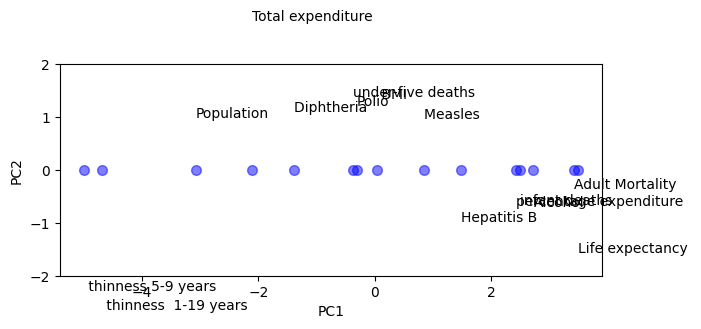

In [ ]:
marker = dict(linestyle='none', marker='o', markersize=7, color='blue', alpha=0.5)
fig, ax = plt.subplots(figsize=(7, 2.75))
ax.plot(PCA1, np.zeros_like(PCA2), label='Scores', **marker)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
_ = ax.set_ylim([-2, 2])

text = [ax.text(x, y, t) for x, y, t in
        zip(PCA1, PCA2, df.columns)]

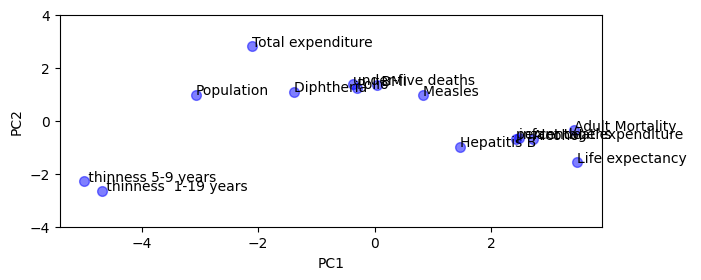

In [ ]:
fig, ax = plt.subplots(figsize=(7, 2.75))
ax.plot(PCA1, PCA2, label='Scores', **marker)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
_ = ax.set_ylim([-4, 4])

text = [ax.text(x, y, t) for x, y, t in
        zip(PCA1, PCA2, df.columns)]

Agora ficou mais fácil de ver as correlações e clusters, por conta dos PCAs aplicados. Isso se deu, ao invés de todas as 10+ colunas, por somente duas (PCA1, PCA2)